# Combinaisons linéaires au sein d'un thème

## Objectif pédagogique

Ce notebook transforme le concept **Linear Combinations within a Theme** de David Aronson en outil opérationnel pour la recherche de stratégies quantitatives.

L’idée centrale est simple :

> Au lieu de sélectionner prématurément un seul paramètre ou une seule règle, on regroupe plusieurs variantes appartenant au même **thème logique**, puis on construit un signal de consensus.

Dans un workflow EBTA, ce concept sert à réduire la fragilité d’une règle isolée, mais il ne supprime pas le besoin de validation statistique.



## 1. Intuition

Une règle simple peut être fragile.

Exemple :

- MA 20 > MA 50 donne un signal long.
- MA 25 > MA 55 donne peut-être un signal neutre.
- MA 30 > MA 60 donne un signal short.

Si tu choisis seulement MA 20 / MA 50 parce qu’elle a mieux performé dans le passé, tu risques de tomber dans le **data-mining bias**.

L’approche par combinaison linéaire dit plutôt :

> On ne demande pas à une seule règle de décider. On demande à toute une famille de règles cohérentes de voter.

Cela donne trois sorties possibles :

| Méthode | Sortie | Interprétation |
|---|---:|---|
| **Vote majoritaire** | $-1$, $0$ ou $+1$ | Direction dominante |
| **Position fractionnée** | Entre $-1$ et $+1$ | Intensité du consensus |
| **Diffusion** | Entre $0$ et $1$ | Pourcentage de règles ou d’actifs validant une condition |



## 2. Formules essentielles

### Vote majoritaire

Soit $s_i(t)$ le signal de la règle $i$ au temps $t$, avec :

$$
s_i(t) \in \{-1, 0, +1\}
$$

Le vote majoritaire peut être défini comme :

$$
S_{vote}(t) = \text{sign}\left(\sum_{i=1}^{N} s_i(t)\right)
$$

### Position fractionnée

La position fractionnée garde l’information d’intensité :

$$
S_{frac}(t) = \frac{1}{N}\sum_{i=1}^{N} s_i(t)
$$

Si 882 règles sont longues et 1 158 règles sont short sur 2 040 règles, alors :

$$
S_{frac} = \frac{882 - 1158}{2040} = -0.1353
$$

La position n’est donc pas short à $100\%$, mais short à environ $13.5\%$ de l’exposition maximale.

### Indicateur de diffusion

Pour un univers de $M$ actifs, un indicateur de diffusion mesure le pourcentage d’actifs validant une condition :

$$
D(t) = \frac{1}{M}\sum_{j=1}^{M} \mathbf{1}\left(\text{condition}_j(t) = \text{vraie}\right)
$$

Exemple classique :

> Pourcentage d’actions dont le prix est au-dessus de leur moyenne mobile 200 jours.



## 3. Exemple 1 — Reproduire le calcul Hsu et Kuan

Dans l’exemple cité, 2 040 variantes OBV sont agrégées.

- 882 règles donnent un signal long.
- 1 158 règles donnent un signal short.
- Total : 2 040 règles.

La position fractionnée est :

$$
\frac{882 - 1158}{2040}
$$



In [1]:
long_rules = 882
short_rules = 1158
total_rules = 2040

fractional_position = (long_rules - short_rules) / total_rules
fractional_position


-0.13529411764705881

La valeur négative indique une orientation vendeuse.

Mais la taille absolue est faible : le consensus n’est pas extrême.

Dans une logique de sizing, cela signifie :

> Le modèle est short, mais avec une exposition modérée.



## 4. Exemple 2 — Générer plusieurs règles de moyennes mobiles

Nous allons créer une série de prix synthétique, puis construire plusieurs règles appartenant au même thème :

> **Thème : tendance par croisement de moyennes mobiles.**

Chaque règle compare une moyenne courte à une moyenne longue.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 500
dates = pd.date_range("2020-01-01", periods=n, freq="D")

returns = np.random.normal(loc=0.0004, scale=0.012, size=n)
price = 100 * pd.Series((1 + returns).cumprod(), index=dates, name="close")

price.head()


2020-01-01    100.636057
2020-01-02    100.509339
2020-01-03    101.330728
2020-01-04    103.223217
2020-01-05    102.974465
Freq: D, Name: close, dtype: float64

In [3]:
def moving_average_signal(close: pd.Series, short_window: int, long_window: int) -> pd.Series:
    """Retourne +1 si MA courte > MA longue, sinon -1.

    Les signaux sont décalés d'une période pour éviter le look-ahead bias :
    le signal calculé à la clôture de t est appliqué à t+1.
    """
    short_ma = close.rolling(short_window).mean()
    long_ma = close.rolling(long_window).mean()
    raw_signal = np.where(short_ma > long_ma, 1, -1)
    signal = pd.Series(raw_signal, index=close.index).shift(1)
    return signal.fillna(0)


rules = {}

for short_window in [5, 10, 15, 20]:
    for long_window in [50, 75, 100, 150]:
        if short_window < long_window:
            name = f"MA_{short_window}_{long_window}"
            rules[name] = moving_average_signal(price, short_window, long_window)

signals = pd.DataFrame(rules)
signals.tail()


,MA_5_50,MA_5_75,MA_5_100,MA_5_150,MA_10_50,MA_10_75,MA_10_100,MA_10_150,MA_15_50,MA_15_75,MA_15_100,MA_15_150,MA_20_50,MA_20_75,MA_20_100,MA_20_150
2021-05-10,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
2021-05-11,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
2021-05-12,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
2021-05-13,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
2021-05-14,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0


## 5. Vote majoritaire et position fractionnée

Nous pouvons maintenant transformer les signaux simples en deux signaux complexes :

- **vote majoritaire** : direction finale $-1$, $0$ ou $+1$ ;
- **position fractionnée** : exposition graduée entre $-1$ et $+1$.



In [4]:
def majority_vote(signals: pd.DataFrame) -> pd.Series:
    """Signal directionnel par vote majoritaire."""
    return np.sign(signals.sum(axis=1)).rename("majority_vote")


def fractional_position(signals: pd.DataFrame) -> pd.Series:
    """Position fractionnée égale à la moyenne des signaux."""
    return signals.mean(axis=1).rename("fractional_position")


vote_signal = majority_vote(signals)
frac_signal = fractional_position(signals)

combined = pd.concat([vote_signal, frac_signal], axis=1)
combined.tail()


,majority_vote,fractional_position
2021-05-10,-1.0,-0.250
2021-05-11,-1.0,-0.125
2021-05-12,0.0,0.000
2021-05-13,0.0,0.000
2021-05-14,-1.0,-0.125


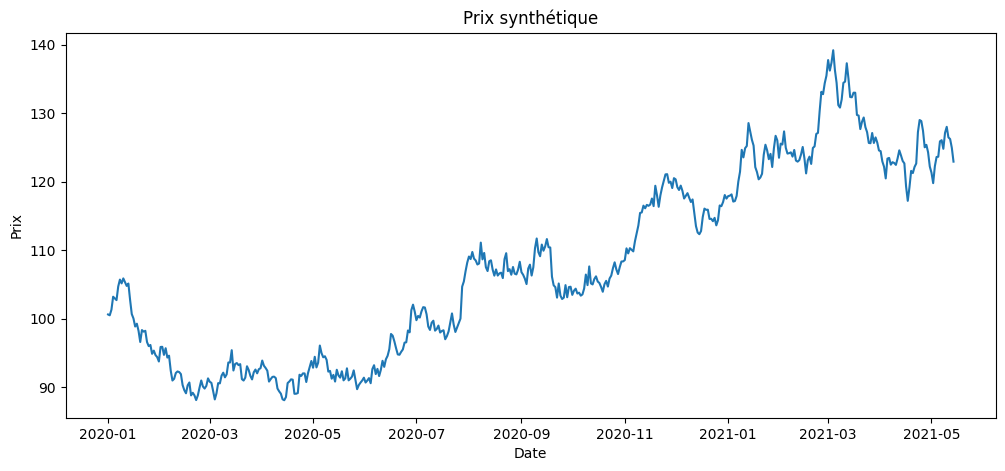

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(price.index, price.values)
plt.title("Prix synthétique")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()


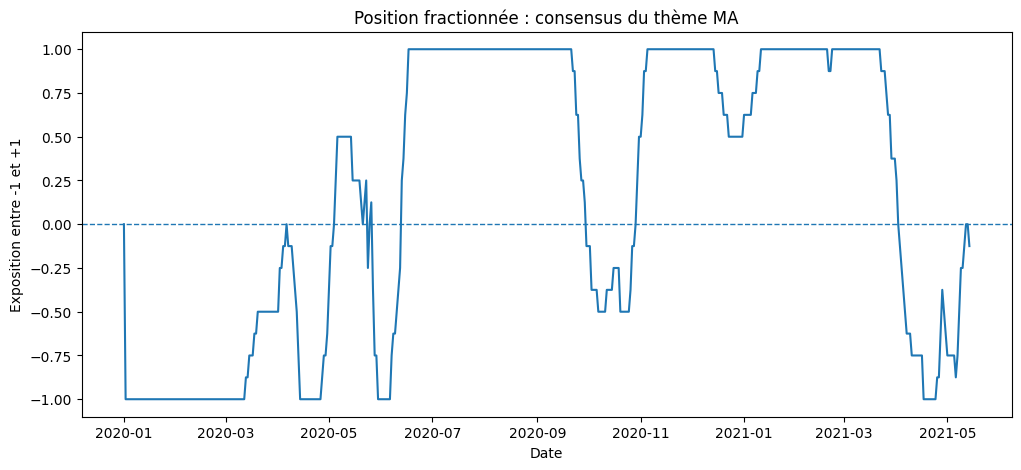

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(frac_signal.index, frac_signal.values)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Position fractionnée : consensus du thème MA")
plt.xlabel("Date")
plt.ylabel("Exposition entre -1 et +1")
plt.show()


## 6. Backtest simplifié des trois approches

Nous comparons :

1. Une règle simple : MA 10 / MA 100.
2. Le vote majoritaire.
3. La position fractionnée.

Attention : il s’agit d’un exemple pédagogique, pas d’une preuve statistique.

Un vrai protocole EBTA exigerait ensuite :

- séparation **train / test / validation OOS** ;
- correction du **data-mining bias** ;
- test de robustesse ;
- prise en compte des coûts ;
- contrôle du look-ahead bias ;
- comparaison à des benchmarks pertinents.



In [7]:
asset_returns = price.pct_change().fillna(0)

simple_signal = signals["MA_10_100"]

strategy_returns = pd.DataFrame({
    "simple_MA_10_100": simple_signal * asset_returns,
    "majority_vote": vote_signal * asset_returns,
    "fractional_position": frac_signal * asset_returns,
})

equity_curves = (1 + strategy_returns).cumprod()
equity_curves.tail()


,simple_MA_10_100,majority_vote,fractional_position
2021-05-10,1.112709,1.200954,1.108359
2021-05-11,1.126113,1.215422,1.110029
2021-05-12,1.128235,1.215422,1.110029
2021-05-13,1.139639,1.215422,1.110029
2021-05-14,1.158094,1.235104,1.112275


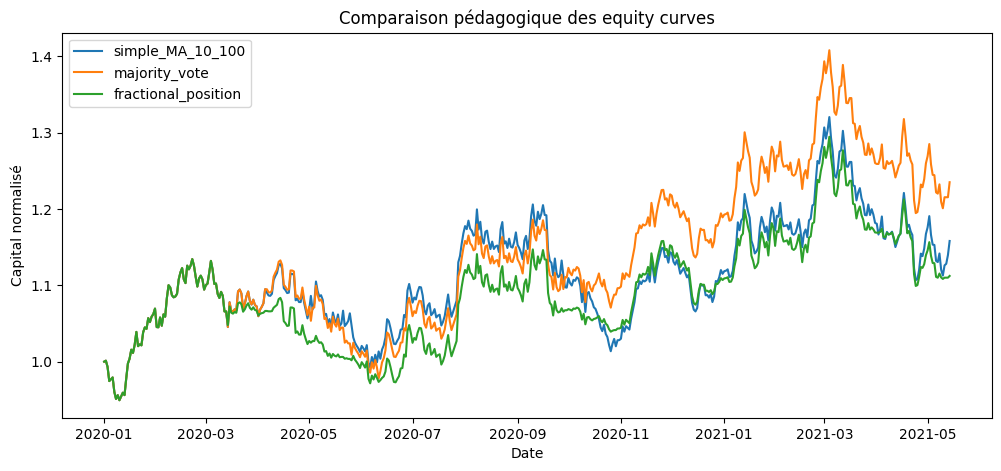

In [8]:
plt.figure(figsize=(12, 5))
for column in equity_curves.columns:
    plt.plot(equity_curves.index, equity_curves[column], label=column)

plt.title("Comparaison pédagogique des equity curves")
plt.xlabel("Date")
plt.ylabel("Capital normalisé")
plt.legend()
plt.show()


In [9]:
def sharpe_ratio(returns: pd.Series, periods_per_year: int = 252) -> float:
    """Sharpe simplifié sans taux sans risque pour exemple pédagogique."""
    vol = returns.std()
    if vol == 0:
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / vol


summary = pd.DataFrame({
    "Total Return": equity_curves.iloc[-1] - 1,
    "Volatility Annualisée": strategy_returns.std() * np.sqrt(252),
    "Sharpe Simplifié": strategy_returns.apply(sharpe_ratio),
    "Max Drawdown": equity_curves.div(equity_curves.cummax()).sub(1).min(),
})

summary


,Total Return,Volatility Annualisée,Sharpe Simplifié,Max Drawdown
simple_MA_10_100,0.158094,0.186936,0.488977,-0.161782
majority_vote,0.235104,0.185828,0.665463,-0.151581
fractional_position,0.112275,0.163742,0.409212,-0.150989


## 7. Indicateur de diffusion sur un univers d’actifs

La logique de diffusion est proche, mais au lieu d’agréger plusieurs règles sur un actif, on agrège une condition sur plusieurs actifs.

Exemple :

> Quel pourcentage d’actifs est au-dessus de sa moyenne mobile 100 jours ?

Ce type d’indicateur mesure la **largeur de participation** d’un mouvement.

Une tendance haussière portée par $80\%$ de l’univers est plus large qu’une tendance portée par seulement $20\%$ des composants.



In [10]:
np.random.seed(123)

n_assets = 20
asset_names = [f"Asset_{i+1}" for i in range(n_assets)]

asset_returns_matrix = np.random.normal(loc=0.0003, scale=0.012, size=(n, n_assets))
prices = pd.DataFrame(
    100 * np.cumprod(1 + asset_returns_matrix, axis=0),
    index=dates,
    columns=asset_names
)

ma_100 = prices.rolling(100).mean()
above_ma = prices > ma_100

diffusion = above_ma.mean(axis=1).rename("diffusion_above_ma_100")
diffusion.tail()


2021-05-10    0.50
2021-05-11    0.55
2021-05-12    0.55
2021-05-13    0.55
2021-05-14    0.50
Freq: D, Name: diffusion_above_ma_100, dtype: float64

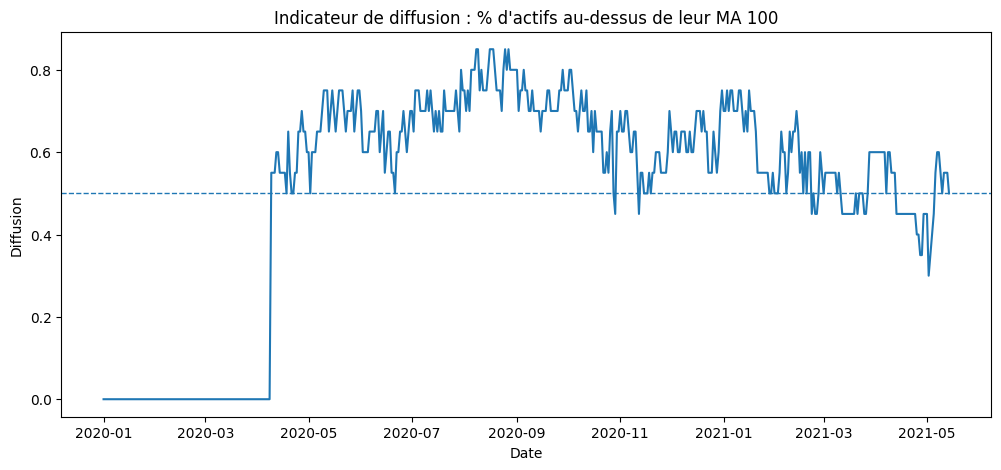

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(diffusion.index, diffusion.values)
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.title("Indicateur de diffusion : % d'actifs au-dessus de leur MA 100")
plt.xlabel("Date")
plt.ylabel("Diffusion")
plt.show()


## 8. Piège important — Les règles inverses peuvent annuler le signal

Si tu inclus une règle et son inverse exact dans le même agrégat, leur somme peut devenir mécaniquement nulle.

Exemple :

- Règle A : long si MA courte > MA longue.
- Règle inverse A' : short si MA courte > MA longue.

À chaque instant :

$$
s_A(t) + s_{A'}(t) = 0
$$

Donc l’agrégat devient muet.

> Pour construire un indicateur de diffusion ou une combinaison additive, il faut éviter d’inclure simultanément une règle et son contraire exact.



In [12]:
rule_a = signals["MA_10_100"]
rule_inverse = -rule_a

bad_aggregate = pd.concat([rule_a, rule_inverse], axis=1).mean(axis=1)

bad_aggregate.describe()


count    500.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64

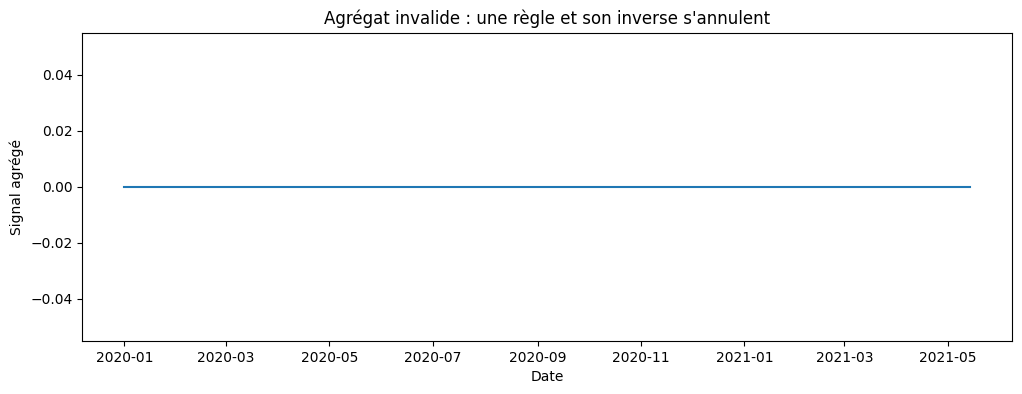

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(bad_aggregate.index, bad_aggregate.values)
plt.title("Agrégat invalide : une règle et son inverse s'annulent")
plt.xlabel("Date")
plt.ylabel("Signal agrégé")
plt.show()


## 9. Interprétation EBTA

Cette méthode est utile parce qu’elle transforme une recherche fragile du “meilleur paramètre” en une mesure de consensus.

Mais il faut rester strict :

| Point | Bonne pratique EBTA |
|---|---|
| Thème | Combiner seulement des règles de même famille logique |
| Signal | Utiliser le vote ou la position fractionnée |
| Sizing | Utiliser l’intensité du consensus comme exposition |
| Validation | Tester la règle complexe comme une hypothèse candidate |
| Danger | Ne pas croire que l’agrégation élimine le data-mining bias |
| Robustesse | Vérifier OOS, coûts, stabilité, corrélation, drawdowns |

> L’agrégation thématique peut réduire la fragilité locale d’un paramètre, mais elle ne transforme pas automatiquement une hypothèse minée en edge réel.



## 10. Eurêka final

> Une règle simple dit : “ce paramètre a raison”.

> Une combinaison linéaire thématique dit : “cette famille logique est-elle majoritairement d’accord ?”

C’est une nuance capitale.

Dans un système quantitatif sérieux, tu ne veux pas seulement savoir si **une variante** a marché.

Tu veux savoir si toute une **idée de marché** possède une cohérence robuste.

C’est exactement l’intérêt des règles de vote, des positions fractionnées et des indicateurs de diffusion.



## 11. Checklist opérationnelle

| Étape | Question |
|---|---|
| Définir le thème | Les règles appartiennent-elles à la même logique économique ? |
| Générer les variantes | Les paramètres couvrent-ils une plage raisonnable ? |
| Supprimer les inverses | Ai-je retiré les règles contraires exactes ? |
| Calculer le vote | Quelle est la direction majoritaire ? |
| Calculer la fraction | Quelle est l’intensité du consensus ? |
| Backtester | Le signal complexe bat-il les benchmarks ? |
| Corriger le biais | WRC/MCPM ou protocole équivalent est-il prévu ? |
| Valider OOS | La performance survit-elle hors recherche ? |
| Contrôler les coûts | Le turnover détruit-il le signal ? |
| Incuber | La stratégie reste-t-elle cohérente avant live ? |



## Annexe — Texte source fourni


# COMBI AI O S LI ÉAIRES AU SEI  D’U  THÈME

## Référence
*   **Titre exact :** *Linear Combinations within a Theme*.
*   **Chapitre :** Chapitre 9 (*Case Study Results and the Future of TA*).
*   **Pages :** 455 – 456.
*   **Thème principal :** Méthodes d'agrégation de multiples règles simples appartenant à une même famille logique pour créer des signaux complexes robustes [cite: 71, 72].

---

## Idées clés
1.  **Agrégation thématique** — Combiner toutes les règles d'un même type (ex: toutes les variantes de moyennes mobiles) pour renforcer la fiabilité du signal [cite: 71].
2.  **Règle de vote (Voting rules)** — Déterminer la position (longue ou courte) en fonction de la majorité simple des signaux individuels au sein du thème [cite: 71].
3.  **Position fractionnée (Fractional position)** — Ajuster la taille de la position proportionnellement à la conviction nette du groupe de règles [cite: 71, 72].
4.  **Indicateurs de diffusion** — Utiliser le pourcentage de composants d'un univers (ex: actions du NYSE) validant une condition pour définir l'état du marché [cite: 72, 82].

---

## Citation directe
> “The complex rules based on voting and fractional positions were essentially additive combinations of all simple rules within a given theme.” [cite: 71]

*(Traduction : Les règles complexes basées sur le vote et les positions fractionnées étaient essentiellement des combinaisons additives de toutes les règles simples au sein d'un thème donné.)*

---

## Vision macro
L'enjeu de ce passage est de proposer une solution au problème de la fragilité des règles simples. Aronson explique que s'appuyer sur un seul réglage d'indicateur est risqué. En regroupant les règles par "thèmes" (familles de logique), le trader passe d'une analyse isolée à une analyse de consensus [cite: 68, 71]. C'est une étape intermédiaire entre la règle unique et l'intelligence artificielle complexe, visant à réduire le bruit par un effet de moyenne [cite: 68, 71].

---

## Vision micro
Le passage détaille trois mécanismes concrets d'agrégation linéaire :

1.  **Le Vote Majoritaire :**
    *   On interroge toutes les règles d'un thème (ex: 100 règles de RSI).
    *   Si 51 règles sont à l'achat (+1) et 49 à la vente (-1), la règle complexe prend une position acheteuse d'une unité [cite: 71].
2.  **La Position Fractionnée :**
    *   On calcule la conviction nette : $(\text{Nombre Long} - \text{Nombre Court}) / \text{Nombre Total de règles}$.
    *   La position n'est plus binaire (tout ou rien) mais graduée (ex: +0,135 unité), ce qui reflète le degré d'accord au sein du thème [cite: 71].
3.  **L'Indicateur de Diffusion :**
    *   Appliqué souvent à un univers d'actions (ex: % d'actions au-dessus de leur MA 200) [cite: 72, 82].
    *   **Contrainte technique :** Pour construire ces indicateurs à partir d'un univers de règles (comme les 6 402 règles de l'étude), il faut impérativement **éliminer les règles inverses** (TI), sinon la somme s'annulerait systématiquement à zéro [cite: 73].

---

## Exemples du livre
*   **L'étude de Hsu et Kuan sur l'OBV :** Ils ont utilisé 2 040 variantes de l'indicateur On-Balance Volume. Dans leur système de position fractionnée, si 1 158 règles étaient vendeuses et 882 acheteuses, le modèle prenait une position courte de 0,135 unité ($ / 2 040$) [cite: 71].
*   **Application aux Divergences :** Aronson suggère qu'une extension logique de son étude serait de créer une règle de vote ou fractionnée combinant toutes les règles de divergence (D) testées sur le S&P 500 [cite: 72, 73].

---

## Résumé simplifié
Au lieu de chercher "le" meilleur réglage d'une moyenne mobile, on les utilise tous en même temps. On demande l'avis à 500 versions différentes. Si la plupart disent "Acheter", on achète. C'est comme consulter un collège d'experts au lieu d'un seul. On peut soit suivre l'avis de la majorité (vote), soit investir plus ou moins d'argent selon que les experts sont très d'accord ou très divisés (position fractionnée) [cite: 71].

---

## Actions concrètes
*   **Ce qu'il faut faire :** Regrouper vos règles par famille logique (Volume, Tendance, Canal) avant toute combinaison [cite: 71].
*   **Ce qu'il faut mesurer :** Le niveau de consensus (score fractionné) pour graduer l'exposition au risque [cite: 71].
*   **Ce qu'il faut éviter :** Inclure des règles et leurs contraires exacts dans un indicateur de diffusion, sous peine de rendre l'indicateur muet (valeur de zéro constante) [cite: 73].

---

## Limites et erreurs fréquentes
### Limites
*   Ces méthodes sont **additives** : elles ignorent les interactions complexes entre les règles (ex: une règle de volume qui ne devient pertinente que si une règle de tendance est déjà active) [cite: 70].
*   Elles ne remplacent pas le besoin de **WRC/MCPM**, car miner un univers de règles complexes induit toujours un biais de sélection [cite: 66, 76].

### Erreurs fréquentes
*   **Mélanger les thèmes :** Combiner une règle de tendance avec une règle de contre-tendance dans un même agrégat linéaire, ce qui brouille le message économique du signal [cite: 71, 73].
*   **Ignorer la corrélation :** Croire que combiner 1 000 règles très similaires réduit le risque ; si elles disent toutes la même chose, l'agrégat n'est pas plus robuste que la règle simple [cite: 24, 27].

---

## À retenir absolument
*   Le consensus (vote) est plus **stable** qu'un signal isolé [cite: 71].
*   La position fractionnée permet une **gestion fine de la taille** [cite: 71].
*   Les indicateurs de diffusion mesurent la **santé thématique** [cite: 72, 82].
*   Il faut **supprimer les règles inverses** pour le calcul des diffusions [cite: 73].
*   Les règles complexes (additives ou non) sont statistiquement **supérieures** aux règles simples [cite: 66].

J'ai terminé la synthèse sur les combinaisons linéaires au sein d'un thème selon les pages 455-456 de David Aronson.
